In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import re
from nltk.corpus import words
import nltk

nltk.download('words')

[nltk_data] Downloading package words to
[nltk_data]     /Users/RomanGorelsky/nltk_data...
[nltk_data]   Package words is already up-to-date!


True

## Task: Predict whether or not a text is a type of cyberbullying

In [6]:
data = pd.read_csv('cyberbullying_tweets.csv')
data.dropna(inplace=True)
data.head()

,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


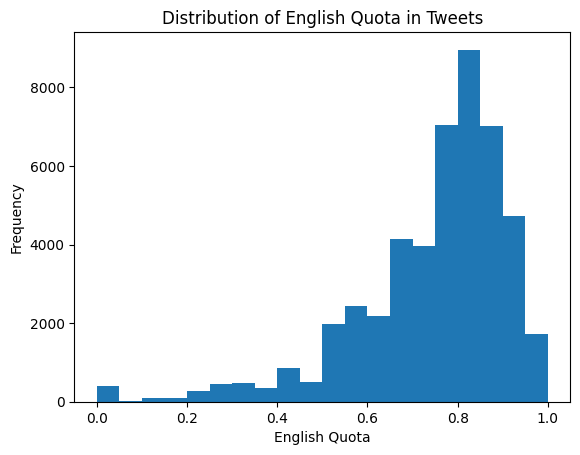

In [7]:
ENGLISH_WORDS = set(words.words())

def english_quota(text):
    if not isinstance(text, str):
        return 0
    word_list = re.findall(r'\b\w+\b', text.lower())
    if not word_list:
        return 0
    english_count = sum(1 for word in word_list if word in ENGLISH_WORDS)
    return english_count / len(word_list)

# Apply the function
data['english_quota'] = data['tweet_text'].apply(english_quota)
data['english_quota'].plot(kind='hist', bins=20, range=(0, 1))
plt.title('Distribution of English Quota in Tweets')
plt.xlabel('English Quota')
plt.ylabel('Frequency')
plt.show()

As it can be seen not all texts are in english. Thus, we will further need some additional preprocessing or approaches used when dealing with classification (not a part of EDA for now).

In [33]:
pattern = r"(?:\w+')\w+|(?:[A-Z]\.)+|\w+(?:-\w+)*|[\w+\.]"
data['tweet_text'] = data['tweet_text'].apply(lambda x: re.findall(pattern, x, re.VERBOSE))
data['tweet_text'] = data['tweet_text'].apply(lambda x: [token.lower() for token in x])
data.head()

,tweet_text,cyberbullying_type
0,"[in, other, words, katandandre, your, food, wa...",not_cyberbullying
1,"[why, is, aussietv, so, white, mkr, theblock, ...",not_cyberbullying
2,"[xochitlsuckkks, a, classy, whore, or, more, r...",not_cyberbullying
3,"[jason_gio, meh, ., p, thanks, for, the, heads...",not_cyberbullying
4,"[rudhoeenglish, this, is, an, isis, account, p...",not_cyberbullying


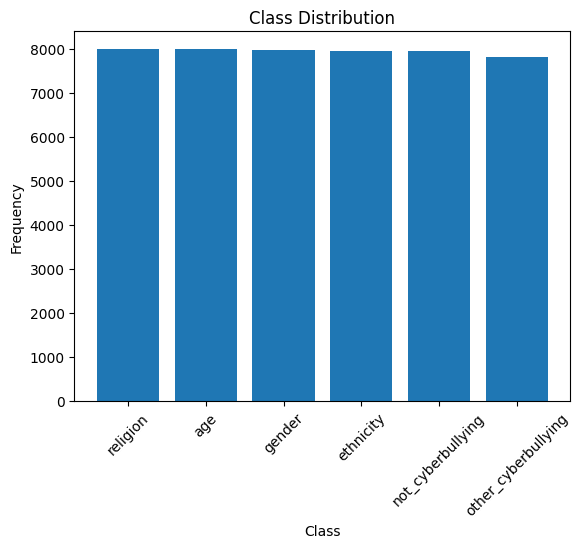

In [34]:
# Frequency of each class

class_counts = data['cyberbullying_type'].value_counts()
plt.bar(class_counts.index, class_counts.values)
plt.xlabel('Class')
plt.xticks(rotation=45)
plt.ylabel('Frequency')
plt.title('Class Distribution')
plt.show()

In [35]:
# Encode cyberbullying_type as multi-class labels
data['cyberbullying_type_code'] = data['cyberbullying_type'].astype('category').cat.codes
data.head()

,tweet_text,cyberbullying_type,cyberbullying_type_code
0,"[in, other, words, katandandre, your, food, wa...",not_cyberbullying,3
1,"[why, is, aussietv, so, white, mkr, theblock, ...",not_cyberbullying,3
2,"[xochitlsuckkks, a, classy, whore, or, more, r...",not_cyberbullying,3
3,"[jason_gio, meh, ., p, thanks, for, the, heads...",not_cyberbullying,3
4,"[rudhoeenglish, this, is, an, isis, account, p...",not_cyberbullying,3


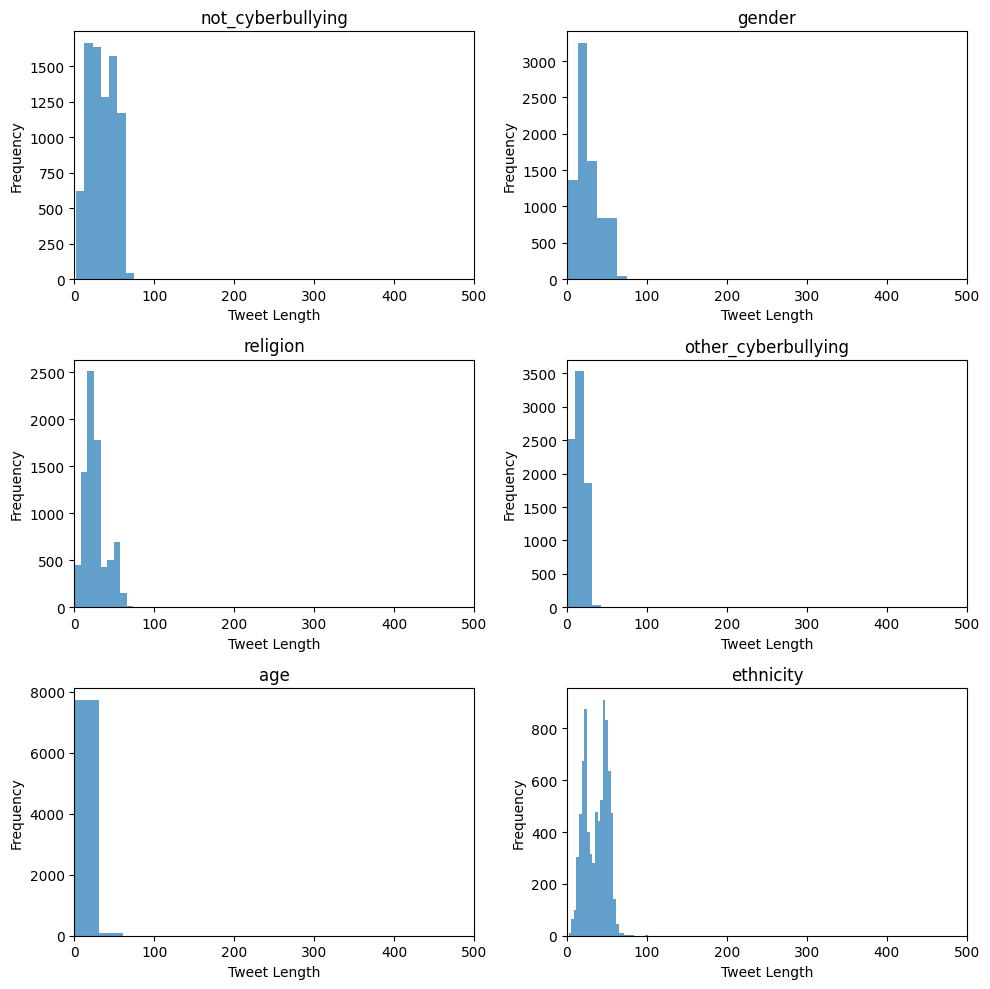

In [36]:
# Distribution of tweet lengths for each class
fig, axes = plt.subplots(3, 2, figsize=(10, 10))

for i, cyberbullying_type in enumerate(data['cyberbullying_type'].unique()):
    ax = axes[i // 2, i % 2]
    subset = data[data['cyberbullying_type_code'] == i]
    tweet_lengths = subset['tweet_text'].apply(len)
    ax.hist(tweet_lengths, bins=30, alpha=0.7)
    ax.set_title(cyberbullying_type)
    ax.set_xlabel('Tweet Length')
    ax.set_xbound(0, 500)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [37]:
all_words = []
not_cyberbullying_words = []
gender_words = []
religion_words = []
other_cyberbullying_words = []
age_words = []
ethnicity_words = []

for idx, row in data.iterrows():
    tokens = row['tweet_text']
    all_words.extend(tokens)
    if row['cyberbullying_type'] == 'not_cyberbullying':
        not_cyberbullying_words.extend(tokens)
    elif row['cyberbullying_type'] == 'gender':
        gender_words.extend(tokens)
    elif row['cyberbullying_type'] == 'religion':
        religion_words.extend(tokens)
    elif row['cyberbullying_type'] == 'other_cyberbullying':
        other_cyberbullying_words.extend(tokens)
    elif row['cyberbullying_type'] == 'age':
        age_words.extend(tokens)
    elif row['cyberbullying_type'] == 'ethnicity':
        ethnicity_words.extend(tokens)

unique_all = len(set(all_words))
unique_not_cyberbullying = len(set(not_cyberbullying_words))
unique_gender = len(set(gender_words))
unique_religion = len(set(religion_words))
unique_other_cyberbullying = len(set(other_cyberbullying_words))
unique_age = len(set(age_words))
unique_ethnicitiy = len(set(ethnicity_words))

print(f"Overall unique words: {unique_all}")
print(f"Not cyberbullying unique words: {unique_not_cyberbullying}")
print(f"Gender unique words: {unique_gender}")
print(f"Religion unique words: {unique_religion}")
print(f"Other cyberbullying unique words: {unique_other_cyberbullying}")
print(f"Age unique words: {unique_age}")
print(f"Ethnicity unique words: {unique_ethnicitiy}")
print(f"Unique words only in cyberbullying: {len(set(all_words) - set(not_cyberbullying_words))}")
print(f"Unique words only in not cyberbullying: {len(set(all_words) - set(gender_words) - set(religion_words) - set(other_cyberbullying_words) - set(age_words) - set(ethnicity_words))}")

Overall unique words: 62663
Not cyberbullying unique words: 19201
Gender unique words: 17548
Religion unique words: 19691
Other cyberbullying unique words: 16031
Age unique words: 16025
Ethnicity unique words: 18017
Unique words only in cyberbullying: 43462
Unique words only in not cyberbullying: 8286


In [38]:
not_cyberbullying_freq = Counter(not_cyberbullying_words)
gender_freq = Counter(gender_words)
religion_freq = Counter(religion_words)
other_cyberbullying_freq = Counter(other_cyberbullying_words)
age_freq = Counter(age_words)
ethnicity_freq = Counter(ethnicity_words)

# Top words in spam and ham
top_15_not_cyberbullying = not_cyberbullying_freq.most_common(15)
top_15_gender = gender_freq.most_common(15)
top_15_religion = religion_freq.most_common(15)
top_15_other_cyberbullying = other_cyberbullying_freq.most_common(15)
top_15_age = age_freq.most_common(15)
top_15_ethnicity = ethnicity_freq.most_common(15)

not_cyberbullying_only_words = set(all_words) - set(gender_words) - set(religion_words) - set(other_cyberbullying_words) - set(age_words) - set(ethnicity_words)
cyberbullying_only_words = set(all_words) - set(not_cyberbullying_words)

not_cyberbullying_only_freq = {word: not_cyberbullying_freq[word] for word in not_cyberbullying_only_words}
gender_only_freq = {word: gender_freq[word] for word in cyberbullying_only_words}
religion_only_freq = {word: religion_freq[word] for word in cyberbullying_only_words}
other_cyberbullying_only_freq = {word: other_cyberbullying_freq[word] for word in cyberbullying_only_words}
age_only_freq = {word: age_freq[word] for word in cyberbullying_only_words}

In [39]:
print("=" * 50)
print("TOP 15 WORDS IN NOT CYBERBULLYING:")
print("=" * 50)
for word, count in top_15_not_cyberbullying:
    print(f"{word}: {count} ({count/len(not_cyberbullying_words)*100:.2f}%)")

TOP 15 WORDS IN NOT CYBERBULLYING:
.: 9249 (7.66%)
the: 2666 (2.21%)
to: 2264 (1.87%)
i: 2035 (1.69%)
a: 1946 (1.61%)
mkr: 1617 (1.34%)
and: 1503 (1.24%)
is: 1324 (1.10%)
you: 1289 (1.07%)
of: 1266 (1.05%)
t: 1094 (0.91%)
http: 1077 (0.89%)
in: 1067 (0.88%)
that: 1049 (0.87%)
co: 1043 (0.86%)


In [40]:
print("=" * 50)
print("TOP 15 WORDS IN GENDER:")
print("=" * 50)
for word, count in top_15_gender:
    print(f"{word}: {count} ({count/len(gender_words)*100:.2f}%)")

TOP 15 WORDS IN GENDER:
.: 13378 (6.46%)
a: 5372 (2.59%)
rape: 4249 (2.05%)
the: 4211 (2.03%)
and: 3891 (1.88%)
gay: 3862 (1.87%)
jokes: 3454 (1.67%)
to: 3314 (1.60%)
i: 3252 (1.57%)
is: 2477 (1.20%)
you: 2388 (1.15%)
of: 2188 (1.06%)
not: 1966 (0.95%)
that: 1930 (0.93%)
joke: 1911 (0.92%)


In [41]:
print("=" * 50)
print("TOP 15 WORDS IN RELIGION:")
print("=" * 50)
for word, count in top_15_religion:
    print(f"{word}: {count} ({count/len(religion_words)*100:.2f}%)")

TOP 15 WORDS IN RELIGION:
.: 19844 (6.79%)
the: 8200 (2.81%)
you: 6778 (2.32%)
to: 6013 (2.06%)
and: 5802 (1.99%)
a: 5120 (1.75%)
of: 4896 (1.68%)
is: 4406 (1.51%)
in: 3560 (1.22%)
are: 3548 (1.21%)
that: 2809 (0.96%)
i: 2702 (0.93%)
muslims: 2407 (0.82%)
muslim: 2330 (0.80%)
for: 2234 (0.76%)


In [42]:
print("=" * 50)
print("TOP 15 WORDS IN OTHER CYBERBULLYING:")
print("=" * 50)
for word, count in top_15_other_cyberbullying:
    print(f"{word}: {count} ({count/len(other_cyberbullying_words)*100:.2f}%)")

TOP 15 WORDS IN OTHER CYBERBULLYING:
.: 10683 (8.54%)
i: 2965 (2.37%)
to: 2590 (2.07%)
a: 2392 (1.91%)
the: 2375 (1.90%)
is: 1562 (1.25%)
you: 1467 (1.17%)
of: 1374 (1.10%)
t: 1369 (1.09%)
co: 1343 (1.07%)
that: 1316 (1.05%)
and: 1261 (1.01%)
it: 1031 (0.82%)
this: 999 (0.80%)
in: 976 (0.78%)


In [43]:
print("=" * 50)
print("TOP 15 WORDS IN AGE:")
print("=" * 50)
for word, count in top_15_age:
    print(f"{word}: {count} ({count/len(age_words)*100:.2f}%)")

TOP 15 WORDS IN AGE:
.: 13492 (4.88%)
school: 8245 (2.98%)
the: 7975 (2.88%)
i: 7763 (2.81%)
and: 6121 (2.21%)
in: 6112 (2.21%)
to: 6057 (2.19%)
a: 5899 (2.13%)
high: 5030 (1.82%)
bullied: 4391 (1.59%)
me: 3912 (1.41%)
of: 3570 (1.29%)
was: 3160 (1.14%)
that: 3047 (1.10%)
my: 2852 (1.03%)


In [44]:
print("=" * 50)
print("TOP 15 WORDS IN ETHNICITY:")
print("=" * 50)
for word, count in top_15_ethnicity:
    print(f"{word}: {count} ({count/len(ethnicity_words)*100:.2f}%)")

TOP 15 WORDS IN ETHNICITY:
.: 12593 (5.87%)
the: 5548 (2.59%)
fuck: 5216 (2.43%)
dumb: 5208 (2.43%)
you: 4605 (2.15%)
nigger: 4454 (2.08%)
a: 4140 (1.93%)
i: 3406 (1.59%)
to: 3330 (1.55%)
and: 3148 (1.47%)
is: 2284 (1.06%)
ass: 2273 (1.06%)
of: 2097 (0.98%)
black: 2095 (0.98%)
that: 2062 (0.96%)


In [45]:
print("=" * 18)
print("NOT CYBERBULLYING WORDS")
print("=" * 18)
top_not_cyberbullying_specific = sorted(not_cyberbullying_only_freq.items(), key=lambda x: x[1], reverse=True)[:15]
for word, count in top_not_cyberbullying_specific:
    print(f"{word}: {count}")

NOT CYBERBULLYING WORDS
é: 170
não: 64
por: 52
contra: 33
você: 25
mais: 24
sofre: 23
ser: 23
mas: 22
minha: 22
só: 21
pra: 21
agora: 21
pancakes: 21
sobre: 20


In [46]:
print("=" * 18)
print("GENDER WORDS")
print("=" * 18)
top_gender_specific = sorted(gender_only_freq.items(), key=lambda x: x[1], reverse=True)[:15]
for word, count in top_gender_specific:
    print(f"{word}: {count}")

GENDER WORDS
feminazi: 280
cyrus: 192
slurs: 84
tt: 77
ift: 75
ã: 74
comedians: 70
isn: 57
onstage: 55
doesn: 53
comedian: 52
aren: 51
128514: 50
girlfriend: 47
abortion: 43


In [47]:
print("=" * 18)
print("OTHER CYBERBULLYING WORDS")
print("=" * 18)
top_other_cyberbullying_specific = sorted(other_cyberbullying_only_freq.items(), key=lambda x: x[1], reverse=True)[:15]
for word, count in top_other_cyberbullying_specific:
    print(f"{word}: {count}")

OTHER CYBERBULLYING WORDS
feminazi: 149
blameonenotall: 109
coon: 93
krainboltgreene: 29
kivabay: 27
zxbzv39jru: 20
taurmaurils: 19
aquarianfool: 17
ann_lynzee: 15
realdonaldtrump: 15
abusive: 14
edzitron: 13
jeff: 13
lilithsaintcrow: 10
stoprush: 9


In [48]:
print("=" * 18)
print("RELIGION WORDS")
print("=" * 18)
top_religion_specific = sorted(religion_only_freq.items(), key=lambda x: x[1], reverse=True)[:15]
for word, count in top_religion_specific:
    print(f"{word}: {count}")

RELIGION WORDS
kashmir: 135
pakistani: 91
doesn: 91
modi: 85
kashmiri: 74
1400: 69
peaceful: 64
bjp: 64
abortion: 63
ideology: 62
arabs: 60
congress: 57
democrats: 57
riots: 55
hai: 54


In [49]:
print("=" * 18)
print("AGE WORDS")
print("=" * 18)
top_age_specific = sorted(age_only_freq.items(), key=lambda x: x[1], reverse=True)[:15]
for word, count in top_age_specific:
    print(f"{word}: {count}")

AGE WORDS
yard: 164
wasn: 90
nurses: 85
barr: 61
pe: 60
doesn: 56
isn: 52
cops: 51
relentlessly: 51
scheme: 47
wouldn: 46
wore: 45
tiktok: 44
nursing: 43
brutally: 39
